In [54]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [55]:
project_root_path = "../../"
customers_path = project_root_path + "data/customers.parquet"

In [56]:
# Load customers table
customers = duckdb.read_parquet(customers_path)

# Sales
purchase = duckdb.sql("SELECT * FROM customers WHERE event_type = 'purchase'")

In [ ]:
# Number of orders per customers
nb_sessions = duckdb.sql(
"""
SELECT user_id, COUNT(DISTINCT user_session) AS nb_sessions
FROM purchase
GROUP BY user_id
ORDER BY nb_sessions ASC
""").fetchnumpy()['nb_sessions']

#Money spent per customer
total_spent = duckdb.sql(
"""
SELECT user_id, SUM(price) AS total_spent
FROM purchase
GROUP BY user_id
ORDER BY total_spent ASC
""").fetchnumpy()['total_spent']

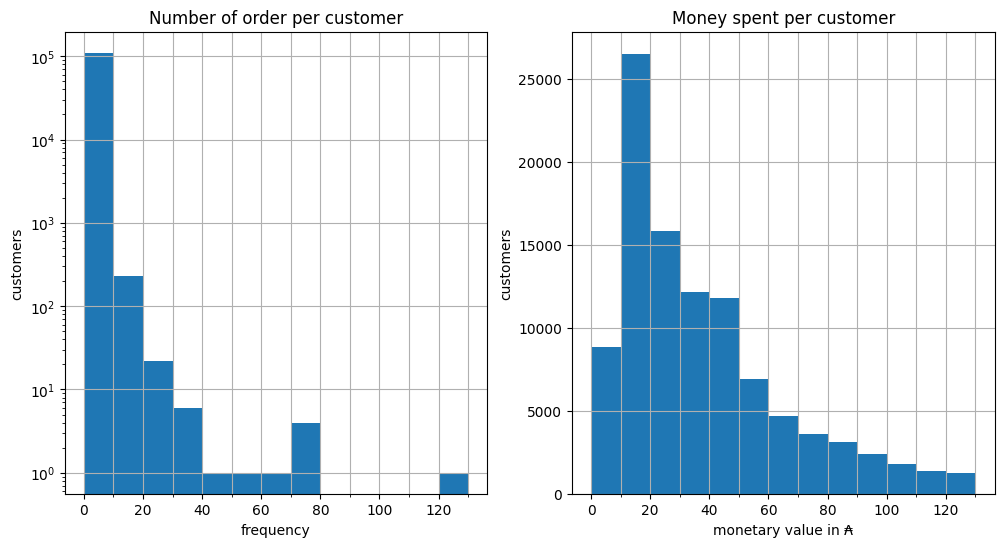

In [58]:
bins = [x for x in range(0, nb_sessions.max() + 10, 10)]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].set_title('Number of order per customer')
axs[0].hist(nb_sessions, bins=bins)
axs[0].set_xlabel('frequency')
axs[0].set_ylabel('customers')
axs[0].set_yscale('log', base=10)

axs[1].set_title('Money spent per customer')
axs[1].hist(total_spent, bins=bins)
axs[1].set_xlabel('monetary value in ₳')
axs[1].set_ylabel('customers')


for ax in axs:
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.grid(True, which='both', axis='x')
    ax.grid(True, which='major', axis='y')


plt.show()